In [1]:
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:
import celldyc as cdc
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

In [3]:
adata = cdc.datasets.celegans()
adata

Saved to: data\GSE126954_ab_unique.h5ad


AnnData object with n_obs × n_vars = 333 × 20222
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'cell.type', 'cell.subtype', 'plot.cell.type', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'passed_initial_QC_or_later_whitelisted', 'cell_generation'
    var: 'features', 'genes'
    uns: 'time.point_colors'
    obsm: 'X_umap'

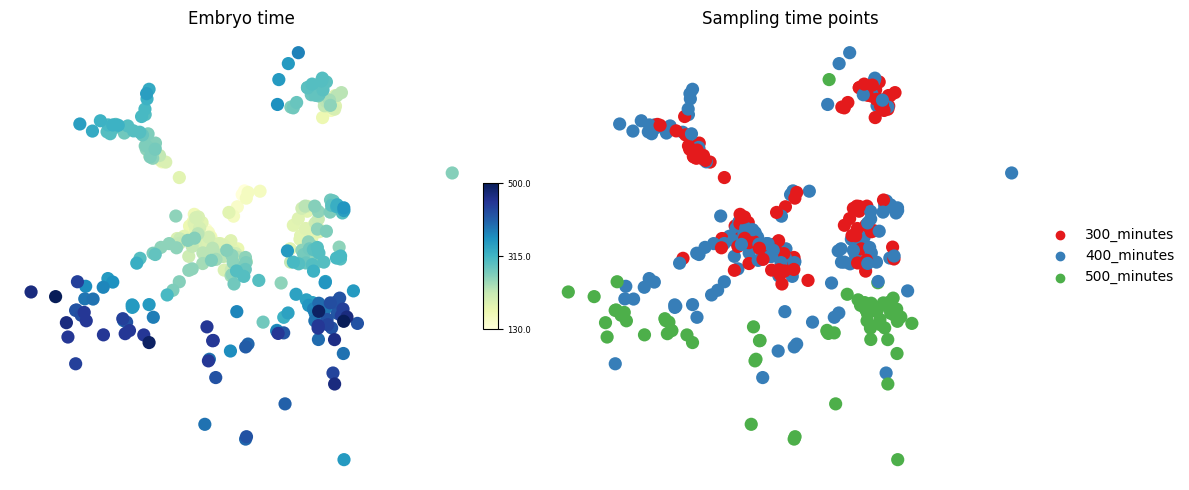

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.886128,trend_loss=0.878601,time_loss=0.752603
epoch  51:loss=0.200148,trend_loss=0.199435,time_loss=0.071356
epoch 101:loss=0.121064,trend_loss=0.120555,time_loss=0.050872
epoch 151:loss=0.105269,trend_loss=0.104800,time_loss=0.046911
epoch 201:loss=0.093951,trend_loss=0.093566,time_loss=0.038456
epoch 251:loss=0.089584,trend_loss=0.089295,time_loss=0.028932
Early stopping at epoch 280


  0%|          | 0/333 [00:00<?, ?cells/s]

computing velocity graph
finished.


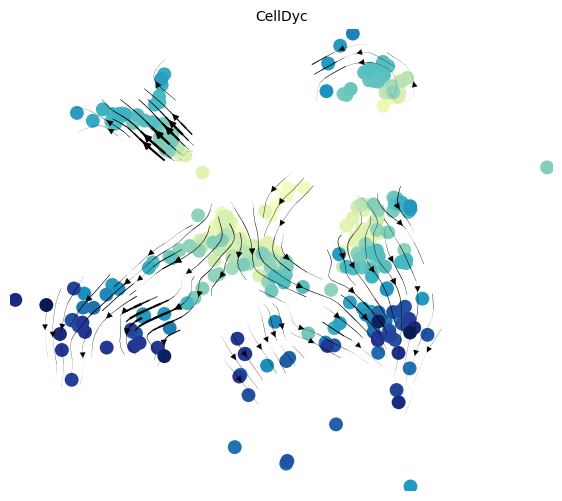

computing velocity embedding
finished.


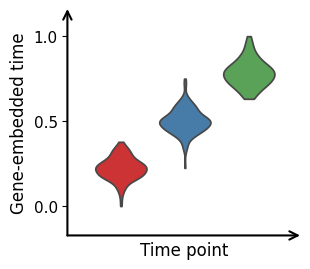

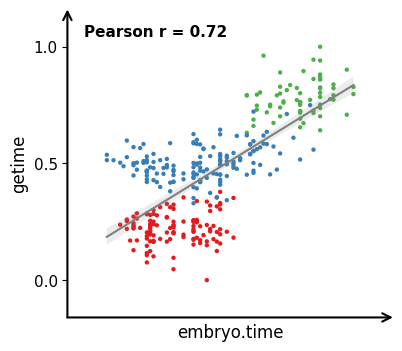

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(adata, color="embryo.time", cmap="YlGnBu",
           frameon=False, title="Embryo time", ax=axs[0], show=False)
axs[0].collections[0].colorbar.remove()
norm = Normalize(vmin=adata.obs["embryo.time"].min(),
                 vmax=adata.obs["embryo.time"].max())
sm = cm.ScalarMappable(norm=norm, cmap="YlGnBu")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs[0], orientation="vertical",
                    fraction=0.03, pad=0.02, aspect=10, shrink=0.7)
cbar.set_ticks([t_min:=(v:=adata.obs["embryo.time"]).min(),
                (v.min()+v.max())/2,
                v.max()])
cbar.set_ticklabels([f"{t:.1f}" for t in cbar.get_ticks()])
cbar.ax.tick_params(labelsize=6)
sc.pl.umap(adata, color="time.point",
           palette=["#e41a1c", "#377eb8", "#4daf4a"],
           frameon=False, title="Sampling time points", ax=axs[1], show=False)
plt.tight_layout()
plt.show()
adata = cdc.tl.preprocess(adata, n_neighbors=40, n_pcs=20)
cat_map = {'300_minutes': 300,
           '400_minutes': 400,
           '500_minutes': 500}
adata.obs['numerical_time'] = adata.obs['time.point'].map(cat_map).astype('category')

adata_wot=adata.copy()
adata_moscot=adata.copy()
cdc.tl.recover_dyc(adata, time_key="numerical_time", time_weight=0.01)
cdc.pl.plot_velocity_projection(adata, color='embryo.time',figsize=(7,6), size=400, 
                                cmap='YlGnBu', alpha=1,title="CellDyc",colorbar=False)
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',
                        palette=["#e41a1c", "#377eb8", "#4daf4a"])
cdc.pl.getime_correlation(adata, 'embryo.time', 'getime', 'numerical_time',
                             palette=["#e41a1c", "#377eb8", "#4daf4a"])

  0%|          | 0/333 [00:00<?, ?cells/s]

computing velocity graph
finished.


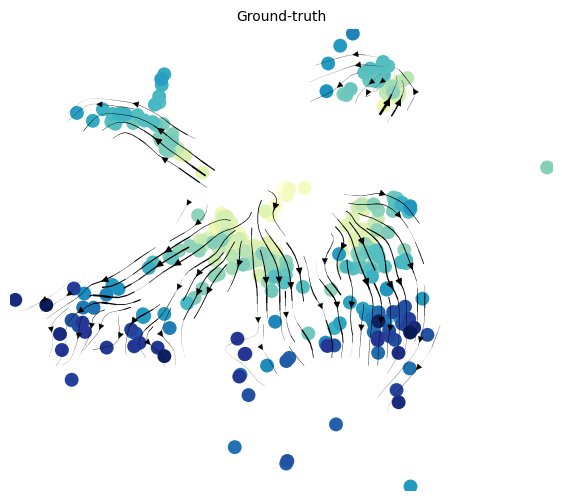

computing velocity embedding
finished.


In [5]:
velocity = cdc.rp.calculate_lineage_velocity(adata)
adata.layers["velocity_true"] = velocity
cdc.pl.plot_velocity_projection(adata, velocity_key='velocity_true', color='embryo.time',
                                figsize=(7,6), size=400, cmap='YlGnBu', alpha=1, graph_T=True,title="Ground-truth",colorbar=False)

  0%|          | 0/2 [00:00<?, ?time pair/s]

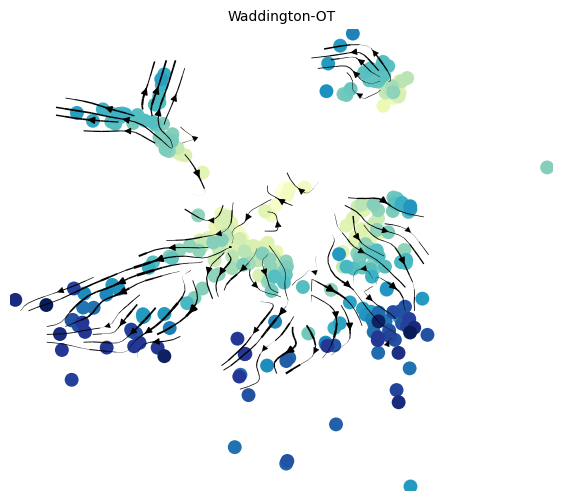

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(152, 65)].                                     
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(116, 152)].                                    
WARNING  Solver did not converge                                                                                   


  0%|          | 0/2 [00:00<?, ?time pair/s]

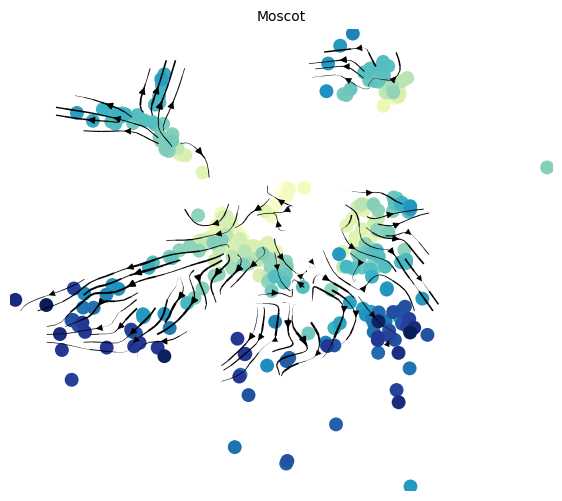

In [6]:
import moscot as mt
import cellrank as cr
import wot
ot_model = wot.ot.OTModel(adata_wot, day_field="numerical_time")
ot_model.compute_all_transport_maps(tmap_out="elegans/")
rtk = cr.kernels.RealTimeKernel.from_wot(adata_wot, path="elegans/", time_key="numerical_time")
rtk = rtk.compute_transition_matrix()
with plt.rc_context({'axes.grid': False, 'grid.linewidth': 0}):
    rtk.plot_projection(basis="umap",connectivities=adata_wot.obsp["connectivities"],color="embryo.time", frameon=False, legend_loc="none",title="Waddington-OT",size=400,cmap='YlGnBu',alpha=1,figsize=(7,6),colorbar=False)

problem = mt.problems.TemporalProblem(adata_moscot)
problem = problem.prepare(time_key="numerical_time").solve()
rtk = cr.kernels.RealTimeKernel.from_moscot(problem)
rtk = rtk.compute_transition_matrix()
with plt.rc_context({'axes.grid': False, 'grid.linewidth': 0}):
    rtk.plot_projection(basis="umap",connectivities=adata_moscot.obsp["connectivities"],color="embryo.time", frameon=False, legend_loc="none",title="Moscot",size=400,cmap='YlGnBu',alpha=1,figsize=(7,6),colorbar=False)
